In [9]:
from google.colab import files

uploaded = files.upload()

Saving assessments.csv to assessments.csv
Saving courses.csv to courses.csv
Saving studentAssessment.csv to studentAssessment.csv
Saving studentInfo.csv to studentInfo.csv
Saving studentRegistration.csv to studentRegistration.csv
Saving studentVle.csv to studentVle.csv
Saving vle.csv to vle.csv


# Uploaded Datasets

In [10]:
import pandas as pd
import numpy as np


In [11]:
assessments = pd.read_csv("assessments.csv")
courses = pd.read_csv("courses.csv")
studentAssessment = pd.read_csv("studentAssessment.csv")
studentInfo = pd.read_csv("studentInfo.csv")
studentRegistration = pd.read_csv("studentRegistration.csv")
studentVle = pd.read_csv("studentVle.csv")
vle = pd.read_csv("vle.csv")

In [13]:
assessments.head()

,code_module,code_presentation,id_assessment,assessment_type,date,weight
0,AAA,2013J,1752,TMA,19,10.0
1,AAA,2013J,1753,TMA,54,20.0
2,AAA,2013J,1754,TMA,117,20.0
3,AAA,2013J,1755,TMA,166,20.0
4,AAA,2013J,1756,TMA,215,30.0


In [14]:
courses.head()

,code_module,code_presentation,module_presentation_length
0,AAA,2013J,268
1,AAA,2014J,269
2,BBB,2013J,268
3,BBB,2014J,262
4,BBB,2013B,240


In [15]:
studentAssessment.head()

,id_assessment,id_student,date_submitted,is_banked,score
0,1752,11391,18,0,78
1,1752,28400,22,0,70
2,1752,31604,17,0,72
3,1752,32885,26,0,69
4,1752,38053,19,0,79


In [16]:
studentInfo.head()

,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass


In [17]:
studentRegistration.head()

,code_module,code_presentation,id_student,date_registration,date_unregistration
0,AAA,2013J,11391,-159,?
1,AAA,2013J,28400,-53,?
2,AAA,2013J,30268,-92,12
3,AAA,2013J,31604,-52,?
4,AAA,2013J,32885,-176,?


In [18]:
studentVle.head()

,code_module,code_presentation,id_student,id_site,date,sum_click
0,AAA,2013J,28400,546652,-10,4
1,AAA,2013J,28400,546652,-10,1
2,AAA,2013J,28400,546652,-10,1
3,AAA,2013J,28400,546614,-10,11
4,AAA,2013J,28400,546714,-10,1


In [19]:
vle.head()

,id_site,code_module,code_presentation,activity_type,week_from,week_to
0,546943,AAA,2013J,resource,?,?
1,546712,AAA,2013J,oucontent,?,?
2,546998,AAA,2013J,resource,?,?
3,546888,AAA,2013J,url,?,?
4,547035,AAA,2013J,resource,?,?


## Put the Tables into an Array

In [20]:
tables = {
    "assessments": assessments,
    "courses": courses,
    "studentAssessment": studentAssessment,
    "studentInfo": studentInfo,
    "studentRegistration": studentRegistration,
    "studentVle": studentVle,
    "vle": vle
}

## Check missing values properly

In [21]:
for name, table in tables.items():
    print(f"\n{name}")
    print(table.head())
    print(table.info())


assessments
  code_module code_presentation  id_assessment assessment_type date  weight
0         AAA             2013J           1752             TMA   19    10.0
1         AAA             2013J           1753             TMA   54    20.0
2         AAA             2013J           1754             TMA  117    20.0
3         AAA             2013J           1755             TMA  166    20.0
4         AAA             2013J           1756             TMA  215    30.0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 206 entries, 0 to 205
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   code_module        206 non-null    object 
 1   code_presentation  206 non-null    object 
 2   id_assessment      206 non-null    int64  
 3   assessment_type    206 non-null    object 
 4   date               206 non-null    object 
 5   weight             206 non-null    float64
dtypes: float64(1), int64(1), object(4)
mem

## Check duplicates

In [22]:
for table in tables.values():
    table.replace('?', np.nan, inplace=True)

# 📊 IMPORTANT OBSERVATIONS ABOUT YOUR DATA
studentVle is HUGE

10.6 million rows

This table contains:

student interaction behavior

This is MOST valuable table for:

engagement analysis
dropout prediction
learning analytics

## Convert important columns to numeric

In [23]:
assessments['date'] = pd.to_numeric(
    assessments['date'],
    errors='coerce'
)

In [24]:
studentAssessment['score'] = pd.to_numeric(
    studentAssessment['score'],
    errors='coerce'
)

In [25]:
studentRegistration['date_registration'] = pd.to_numeric(
    studentRegistration['date_registration'],
    errors='coerce'
)

studentRegistration['date_unregistration'] = pd.to_numeric(
    studentRegistration['date_unregistration'],
    errors='coerce'
)

In [26]:
vle['week_from'] = pd.to_numeric(
    vle['week_from'],
    errors='coerce'
)

vle['week_to'] = pd.to_numeric(
    vle['week_to'],
    errors='coerce'
)

In [27]:
assessments.info()
studentAssessment.info()
studentRegistration.info()
vle.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 206 entries, 0 to 205
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   code_module        206 non-null    object 
 1   code_presentation  206 non-null    object 
 2   id_assessment      206 non-null    int64  
 3   assessment_type    206 non-null    object 
 4   date               195 non-null    float64
 5   weight             206 non-null    float64
dtypes: float64(2), int64(1), object(3)
memory usage: 9.8+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 173912 entries, 0 to 173911
Data columns (total 5 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   id_assessment   173912 non-null  int64  
 1   id_student      173912 non-null  int64  
 2   date_submitted  173912 non-null  int64  
 3   is_banked       173912 non-null  int64  
 4   score           173739 non-null  float64
dtypes: float64(1)

# CREATE ENGAGEMENT FEATURES
## create summarized engagement features from studentVle

In [28]:
student_vle_summary = studentVle.groupby(
    ['id_student', 'code_module', 'code_presentation']
).agg(
    total_clicks=('sum_click', 'sum'),
    avg_clicks=('sum_click', 'mean'),
    total_interactions=('sum_click', 'count')
).reset_index()

## Check the summarized table

In [29]:
student_vle_summary.head()

,id_student,code_module,code_presentation,total_clicks,avg_clicks,total_interactions
0,6516,AAA,2014J,2791,4.216012,662
1,8462,DDD,2013J,646,2.153333,300
2,8462,DDD,2014J,10,2.500000,4
3,11391,AAA,2013J,934,4.765306,196
4,23629,BBB,2013B,161,2.728814,59


In [30]:
student_vle_summary.shape

(29228, 6)

# Aggregate assessment data

In [31]:
assessment_summary = studentAssessment.groupby(
    'id_student'
).agg(
    avg_score=('score', 'mean'),
    total_assessments=('score', 'count'),
    highest_score=('score', 'max'),
    lowest_score=('score', 'min')
).reset_index()

## Inspect results

In [32]:
assessment_summary.head()

,id_student,avg_score,total_assessments,highest_score,lowest_score
0,6516,61.800000,5,77.0,48.0
1,8462,87.000000,7,93.0,83.0
2,11391,82.000000,5,85.0,78.0
3,23629,82.500000,4,100.0,63.0
4,23698,74.444444,9,94.0,56.0


In [33]:
assessment_summary.shape

(23369, 5)

# NEXT STEP AFTER THAT

We will finally start building the denormalized master dataset by merging:

Source	                       Purpose
studentInfo	                   demographics + target
assessment_summary	           academic performance
student_vle_summary	           engagement behavior
studentRegistration	           registration behavior

In [34]:
assessment_summary.shape

(23369, 5)

## Right Now i have created TWO summarized feature tables

| Table                 | Purpose                     |
| --------------------- | --------------------------- |
| `student_vle_summary` | student engagement behavior |
| `assessment_summary`  | academic performance        |


# 🎯 THE REAL GOAL NOW

want to build:

ONE MASTER ANALYTICAL DATASET

This is called:

denormalized dataset
analytical base table
ML-ready dataset

Instead of many separate tables.

# 📌 WHAT WE WILL MERGE INTO IT
## 1️⃣ assessment_summary

Adds:

avg_score
highest_score
participation
## 2️⃣ student_vle_summary

Adds:

engagement behavior
interaction intensity
## 3️⃣ studentRegistration

Adds:

registration timing
withdrawal information
## 📊 Final Dataset Structure

| Feature Type | Examples                  |
| ------------ | ------------------------- |
| Demographics | gender, region, education |
| Academic     | avg_score                 |
| Engagement   | total_clicks              |
| Behavior     | registration timing       |
| Target       | final_result              |


# 🎯 WHAT THIS ENABLES LATER

I can build:

dropout prediction
student success prediction
engagement analysis
at-risk student identification

These are REAL EdTech analytics problems.

# 🚀 NOW WE START MERGING

## Merge assessment summary into studentInfo

In [35]:
master_df = pd.merge(
    studentInfo,
    assessment_summary,
    on='id_student',
    how='left'
)

In [36]:
studentInfo

,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass
...,...,...,...,...,...,...,...,...,...,...,...,...
32588,GGG,2014J,2640965,F,Wales,Lower Than A Level,10-20,0-35,0,30,N,Fail
32589,GGG,2014J,2645731,F,East Anglian Region,Lower Than A Level,40-50%,35-55,0,30,N,Distinction
32590,GGG,2014J,2648187,F,South Region,A Level or Equivalent,20-30%,0-35,0,30,Y,Pass
32591,GGG,2014J,2679821,F,South East Region,Lower Than A Level,90-100%,35-55,0,30,N,Withdrawn


## It merge
avg_score
highest_score
lowest_score
total_assessments

for each student.

In [37]:
master_df.head()

,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,avg_score,total_assessments,highest_score,lowest_score
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass,82.0,5.0,85.0,78.0
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass,66.4,5.0,70.0,60.0
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn,NaN,NaN,NaN,NaN
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass,76.0,5.0,88.0,71.0
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass,54.4,5.0,75.0,30.0


In [38]:
master_df.shape

(32593, 16)

# What we now have

Your **master_df** currently contains:

Demographics
gender
region
education
age_band
disability
Academic Features
avg_score
highest_score
lowest_score
total_assessments
Target Variable
final_result

This is already becoming a strong analytical dataset.

## MERGE ENGAGEMENT FEATURES

In [39]:
student_vle_summary

,id_student,code_module,code_presentation,total_clicks,avg_clicks,total_interactions
0,6516,AAA,2014J,2791,4.216012,662
1,8462,DDD,2013J,646,2.153333,300
2,8462,DDD,2014J,10,2.500000,4
3,11391,AAA,2013J,934,4.765306,196
4,23629,BBB,2013B,161,2.728814,59
...,...,...,...,...,...,...
29223,2698257,AAA,2013J,758,2.838951,267
29224,2698535,CCC,2014B,786,4.136842,190
29225,2698535,EEE,2013J,3455,4.873061,709
29226,2698577,BBB,2014J,717,3.025316,237


## Merge engagement summary

In [40]:
master_df = pd.merge(
    master_df,
    student_vle_summary,
    on=['id_student', 'code_module', 'code_presentation'],
    how='left'
)

## Validate merge

In [41]:
master_df.shape

(32593, 19)

In [42]:
master_df.head()

,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,avg_score,total_assessments,highest_score,lowest_score,total_clicks,avg_clicks,total_interactions
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass,82.0,5.0,85.0,78.0,934.0,4.765306,196.0
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass,66.4,5.0,70.0,60.0,1435.0,3.337209,430.0
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn,NaN,NaN,NaN,NaN,281.0,3.697368,76.0
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass,76.0,5.0,88.0,71.0,2158.0,3.254902,663.0
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass,54.4,5.0,75.0,30.0,1034.0,2.937500,352.0


# ADD REGISTRATION BEHAVIOR

This adds very important lifecycle features:

when student joined
when student left (if they dropped out)

This is critical for:

dropout prediction
retention analysis
student survival behavior

## Prepare registration data

In [43]:
studentRegistration

,code_module,code_presentation,id_student,date_registration,date_unregistration
0,AAA,2013J,11391,-159.0,NaN
1,AAA,2013J,28400,-53.0,NaN
2,AAA,2013J,30268,-92.0,12.0
3,AAA,2013J,31604,-52.0,NaN
4,AAA,2013J,32885,-176.0,NaN
...,...,...,...,...,...
32588,GGG,2014J,2640965,-4.0,NaN
32589,GGG,2014J,2645731,-23.0,NaN
32590,GGG,2014J,2648187,-129.0,NaN
32591,GGG,2014J,2679821,-49.0,101.0


In [44]:
studentRegistration['date_registration'] = pd.to_numeric(studentRegistration['date_registration'], errors='coerce')
studentRegistration['date_unregistration'] = pd.to_numeric(studentRegistration['date_unregistration'], errors='coerce')

## Create registration summary

In [45]:
registration_summary = studentRegistration.groupby(
    ['id_student', 'code_module', 'code_presentation']
).agg(
    date_registration=('date_registration', 'min'),
    date_unregistration=('date_unregistration', 'min')
).reset_index()

## Merge into master dataset

In [46]:
master_df = pd.merge(
    master_df,
    registration_summary,
    on=['id_student', 'code_module', 'code_presentation'],
    how='left'
)

In [47]:
master_df.shape

(32593, 21)

In [48]:
master_df.head(10)

,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,...,final_result,avg_score,total_assessments,highest_score,lowest_score,total_clicks,avg_clicks,total_interactions,date_registration,date_unregistration
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,...,Pass,82.0,5.0,85.0,78.0,934.0,4.765306,196.0,-159.0,NaN
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,...,Pass,66.4,5.0,70.0,60.0,1435.0,3.337209,430.0,-53.0,NaN
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,...,Withdrawn,NaN,NaN,NaN,NaN,281.0,3.697368,76.0,-92.0,12.0
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,...,Pass,76.0,5.0,88.0,71.0,2158.0,3.254902,663.0,-52.0,NaN
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,...,Pass,54.4,5.0,75.0,30.0,1034.0,2.937500,352.0,-176.0,NaN
5,AAA,2013J,38053,M,Wales,A Level or Equivalent,80-90%,35-55,0,60,...,Pass,68.0,5.0,79.0,50.0,2445.0,3.381743,723.0,-110.0,NaN
6,AAA,2013J,45462,M,Scotland,HE Qualification,30-40%,0-35,0,60,...,Pass,68.0,5.0,75.0,62.0,1492.0,4.202817,355.0,-67.0,NaN
7,AAA,2013J,45642,F,North Western Region,A Level or Equivalent,90-100%,0-35,0,120,...,Pass,72.4,5.0,73.0,72.0,1428.0,2.689266,531.0,-29.0,NaN
8,AAA,2013J,52130,F,East Anglian Region,A Level or Equivalent,70-80%,0-35,0,90,...,Pass,71.4,5.0,75.0,68.0,1894.0,3.193929,593.0,-33.0,NaN
9,AAA,2013J,53025,M,North Region,Post Graduate Qualification,NaN,55<=,0,60,...,Pass,78.0,5.0,81.0,71.0,3158.0,3.493363,904.0,-179.0,NaN


# Now I find

## Dropout indicator
if date_unregistration is not null → dropout
## Study duration
duration = date_unregistration - date_registration
## Late registration risk
late_join = high registration date

In [49]:
master_df.shape

(32593, 21)

# What I have done so far

### ✔ Data cleaning
* handled ?
* fixed datatypes
### ✔ Feature aggregation
* student engagement (VLE summary)
* academic performance (assessment summary)
### ✔ Data integration
* studentInfo + engagement + performance + registration

# FEATURE ENGINEERING
* Now we convert raw columns into meaningful ML features

### Create dropout flag

In [50]:
master_df['dropout_flag'] = master_df['date_unregistration'].notna().astype(int)

## Create study duration feature
How long a student stayed

In [51]:
master_df['study_duration'] = (
    master_df['date_unregistration'] - master_df['date_registration']
)

## Fill missing duration

Students who did NOT drop out will have NaN

In [52]:
master_df['study_duration'] = master_df['study_duration'].fillna(
    master_df['study_duration'].max()
)

## Create engagement score

In [53]:
master_df['engagement_score'] = (
    master_df['total_clicks'] / (master_df['total_interactions'] + 1)
)

## Create performance category

In [54]:
def performance_label(score):
    if pd.isna(score):
        return 'Unknown'
    elif score >= 70:
        return 'High'
    elif score >= 40:
        return 'Medium'
    else:
        return 'Low'

master_df['performance_level'] = master_df['avg_score'].apply(performance_label)

## Check new dataset

In [55]:
master_df.head()

,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,...,lowest_score,total_clicks,avg_clicks,total_interactions,date_registration,date_unregistration,dropout_flag,study_duration,engagement_score,performance_level
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,...,78.0,934.0,4.765306,196.0,-159.0,NaN,0,531.0,4.741117,High
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,...,60.0,1435.0,3.337209,430.0,-53.0,NaN,0,531.0,3.329466,Medium
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,...,NaN,281.0,3.697368,76.0,-92.0,12.0,1,104.0,3.649351,Unknown
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,...,71.0,2158.0,3.254902,663.0,-52.0,NaN,0,531.0,3.250000,High
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,...,30.0,1034.0,2.937500,352.0,-176.0,NaN,0,531.0,2.929178,Medium


In [56]:
master_df.shape

(32593, 25)

In [57]:
master_df.sample(10)

,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,...,lowest_score,total_clicks,avg_clicks,total_interactions,date_registration,date_unregistration,dropout_flag,study_duration,engagement_score,performance_level
32015,GGG,2014J,633093,F,East Midlands Region,A Level or Equivalent,70-80%,0-35,0,30,...,45.0,1052.0,3.627586,290.0,-106.0,NaN,0,531.0,3.615120,High
17934,DDD,2014J,504034,F,Ireland,A Level or Equivalent,0-10%,0-35,1,120,...,62.0,4.0,2.000000,2.0,-39.0,47.0,1,86.0,1.333333,Medium
21714,EEE,2014J,650334,M,South West Region,Lower Than A Level,40-50%,0-35,0,60,...,NaN,NaN,NaN,NaN,-129.0,12.0,1,141.0,NaN,Unknown
11760,CCC,2014J,605666,M,East Midlands Region,HE Qualification,60-70%,0-35,0,60,...,67.0,230.0,2.643678,87.0,-38.0,NaN,0,531.0,2.613636,High
23044,FFF,2013B,527991,M,South East Region,A Level or Equivalent,80-90%,0-35,1,120,...,38.0,852.0,3.477551,245.0,-25.0,NaN,0,531.0,3.463415,Medium
18426,DDD,2014J,635992,F,Yorkshire Region,A Level or Equivalent,80-90%,0-35,0,120,...,83.0,1908.0,2.092105,912.0,-157.0,NaN,0,531.0,2.089814,High
13905,DDD,2013B,544603,M,North Region,A Level or Equivalent,0-10%,0-35,0,60,...,0.0,1434.0,2.093431,685.0,-74.0,NaN,0,531.0,2.090379,Medium
2224,BBB,2013B,557935,F,Yorkshire Region,Lower Than A Level,0-10%,0-35,0,60,...,68.0,270.0,2.389381,113.0,-27.0,NaN,0,531.0,2.368421,High
9393,CCC,2014B,555008,M,London Region,A Level or Equivalent,10-20,0-35,0,60,...,46.0,754.0,2.911197,259.0,-46.0,NaN,0,531.0,2.900000,Medium
16655,DDD,2014B,522129,M,North Western Region,A Level or Equivalent,70-80%,35-55,1,120,...,22.0,117.0,2.720930,43.0,-85.0,179.0,1,264.0,2.659091,Low


## I have already done
* cleaning
* merging
* feature engineering

## GOAL
We will build a model to predict:

Will a student drop out or not?

Using:

dropout_flag

classic binary classification problem.

## Define features (X) and target (y)

In [58]:
X = master_df.drop(columns=['dropout_flag', 'final_result'])
y = master_df['dropout_flag']

## Check balance of target

In [59]:
y.value_counts()

,count
dropout_flag,
0,22521
1,10072


# Fix categorical columns

In [60]:
X.isnull().sum().sort_values(ascending=False)

,0
date_unregistration,22521
highest_score,5866
avg_score,5866
lowest_score,5866
total_assessments,5847
avg_clicks,3365
total_clicks,3365
engagement_score,3365
total_interactions,3365
imd_band,1111


In [61]:
X = master_df.drop(columns=['dropout_flag', 'final_result', 'date_unregistration'])

In [62]:
X = X.fillna(X.median(numeric_only=True))


In [63]:
X.isnull().sum().sum()

np.int64(1111)

In [64]:
X = X.fillna(X.median(numeric_only=True))

In [65]:
X.isnull().sum().sum()

np.int64(1111)

In [66]:
X.isnull().sum().sort_values(ascending=False).head(20)

,0
imd_band,1111
code_module,0
id_student,0
gender,0
region,0
code_presentation,0
highest_education,0
age_band,0
num_of_prev_attempts,0
studied_credits,0


In [67]:
X['imd_band'] = X['imd_band'].fillna('Unknown')

In [68]:
X.isnull().sum().sum()

np.int64(0)

In [69]:
X = master_df.drop(columns=['dropout_flag', 'final_result'])
y = master_df['dropout_flag']

In [70]:
X['imd_band'] = X['imd_band'].fillna('Unknown')

In [71]:
X = pd.get_dummies(X, drop_first=True)

In [72]:
X = X.fillna(X.median(numeric_only=True))

# Train/test split

In [73]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Logistic Regression Model

In [74]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [75]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9984660223960731
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4504
           1       1.00      1.00      1.00      2015

    accuracy                           1.00      6519
   macro avg       1.00      1.00      1.00      6519
weighted avg       1.00      1.00      1.00      6519



In [76]:
X = master_df.drop(columns=[
    'dropout_flag',
    'final_result',
    'date_unregistration',
    'study_duration'
])

In [77]:
X = pd.get_dummies(X, drop_first=True)

In [78]:
X = X.fillna(X.median(numeric_only=True))

In [79]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [80]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.7410645804571253
              precision    recall  f1-score   support

           0       0.78      0.86      0.82      4504
           1       0.61      0.47      0.53      2015

    accuracy                           0.74      6519
   macro avg       0.69      0.66      0.67      6519
weighted avg       0.73      0.74      0.73      6519



# Switch to Random Forest

In [81]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced'
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=200,
                       random_state=42)

# Predict

In [82]:
y_pred_rf = rf_model.predict(X_test)

# Evaluate

In [83]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.8456818530449456
              precision    recall  f1-score   support

           0       0.87      0.91      0.89      4504
           1       0.78      0.70      0.74      2015

    accuracy                           0.85      6519
   macro avg       0.83      0.80      0.81      6519
weighted avg       0.84      0.85      0.84      6519



In [84]:
import pandas as pd

feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf_model.feature_importances_
}).sort_values(by='importance', ascending=False)

feature_importance.head(15)

,feature,importance
9,total_interactions,0.131198
4,total_assessments,0.116482
7,total_clicks,0.116374
5,highest_score,0.072326
3,avg_score,0.051945
11,engagement_score,0.050950
52,performance_level_Unknown,0.048794
8,avg_clicks,0.047893
6,lowest_score,0.044508
0,id_student,0.043427


# Visualization

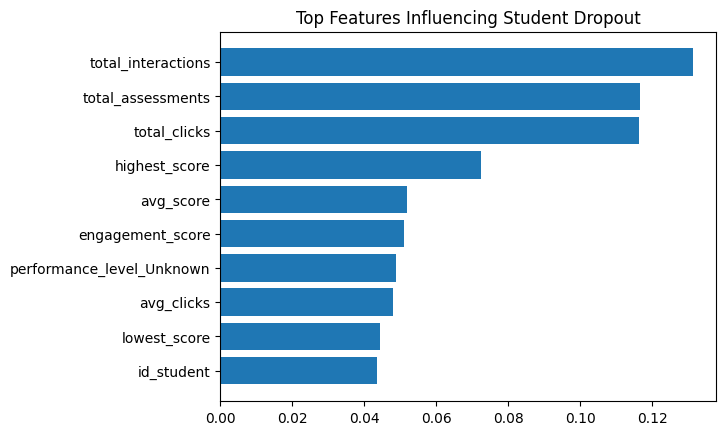

In [85]:
import matplotlib.pyplot as plt

top_features = feature_importance.head(10)

plt.figure()
plt.barh(top_features['feature'], top_features['importance'])
plt.gca().invert_yaxis()
plt.title("Top Features Influencing Student Dropout")
plt.show()

In [86]:
X = X.drop(columns=['id_student'])

# Get probabilities

In [87]:
y_proba = rf_model.predict_proba(X_test)[:, 1]

# Create risk categories

In [88]:
def risk_level(prob):
    if prob < 0.3:
        return "Low Risk"
    elif prob < 0.7:
        return "Medium Risk"
    else:
        return "High Risk"

risk_labels = np.array([risk_level(p) for p in y_proba])

# Build results table

In [89]:
results = X_test.copy()

results['actual_dropout'] = y_test.values
results['predicted_dropout'] = y_pred_rf
results['dropout_probability'] = y_proba
results['risk_level'] = risk_labels

# View highest-risk students

In [90]:
results[['dropout_probability', 'risk_level']].head()

,dropout_probability,risk_level
16225,0.400,Medium Risk
16592,0.045,Low Risk
18,0.345,Medium Risk
17185,0.945,High Risk
7821,0.895,High Risk


In [91]:
high_risk_students = results[
    results['risk_level'] == 'High Risk'
]

high_risk_students.head(10)

,id_student,num_of_prev_attempts,studied_credits,avg_score,total_assessments,highest_score,lowest_score,total_clicks,avg_clicks,total_interactions,...,age_band_35-55,age_band_55<=,disability_Y,performance_level_Low,performance_level_Medium,performance_level_Unknown,actual_dropout,predicted_dropout,dropout_probability,risk_level
17185,625913,0,60,75.714286,7.0,93.0,58.0,739.5,3.080000,242.0,...,False,False,False,False,False,True,1,1,0.945,High Risk
7821,677864,0,180,75.714286,7.0,93.0,58.0,739.5,3.080000,242.0,...,True,False,False,False,False,True,1,1,0.895,High Risk
5882,626485,0,60,75.714286,7.0,93.0,58.0,739.5,3.080000,242.0,...,False,False,False,False,False,True,1,1,0.870,High Risk
19219,1935774,3,60,75.714286,7.0,93.0,58.0,97.0,1.732143,56.0,...,False,False,False,False,False,True,0,1,0.775,High Risk
4740,2648206,0,120,75.714286,7.0,93.0,58.0,739.5,3.080000,242.0,...,False,False,False,False,False,True,1,1,0.870,High Risk
21878,674965,0,210,89.000000,5.0,100.0,67.0,739.5,3.080000,242.0,...,False,False,False,False,False,False,1,1,0.720,High Risk
28029,470121,0,60,75.714286,7.0,93.0,58.0,145.0,4.142857,35.0,...,False,False,False,False,False,True,1,1,0.780,High Risk
15170,542321,1,60,75.714286,7.0,93.0,58.0,739.5,3.080000,242.0,...,True,False,False,False,False,True,1,1,0.880,High Risk
21539,639232,0,120,75.714286,7.0,93.0,58.0,739.5,3.080000,242.0,...,True,False,False,False,False,True,1,1,0.970,High Risk
17841,444625,0,90,75.714286,7.0,93.0,58.0,739.5,3.080000,242.0,...,False,False,False,False,False,True,1,1,0.980,High Risk


In [92]:
results['risk_level'].value_counts()

,count
risk_level,
Low Risk,3856
Medium Risk,1712
High Risk,951


# Risk Summary

In [93]:
risk_summary = results['risk_level'].value_counts()

print(risk_summary)

risk_level
Low Risk       3856
Medium Risk    1712
High Risk       951
Name: count, dtype: int64


In [94]:
results.to_csv("student_dropout_risk_results.csv", index=False)

Developed a machine learning–based student dropout prediction system using the Open University Learning Analytics Dataset (OULAD). Engineered behavioral and academic features from over 10 million LMS interaction records and built predictive models using Logistic Regression and Random Forest. Improved dropout detection performance to 84.5% accuracy and implemented a student risk scoring system to classify learners into Low, Medium, and High dropout risk categories for early intervention analytics.


In [95]:
feature_importance.to_csv("feature_importance.csv", index=False)

# Confusion Matrix Heatmap

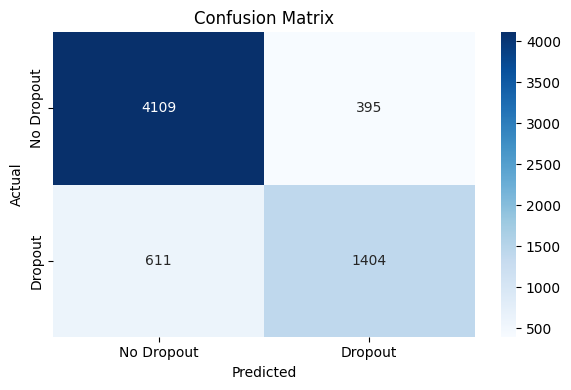

In [96]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Dropout', 'Dropout'],
            yticklabels=['No Dropout', 'Dropout'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

#  Classification Report as a Heatmap

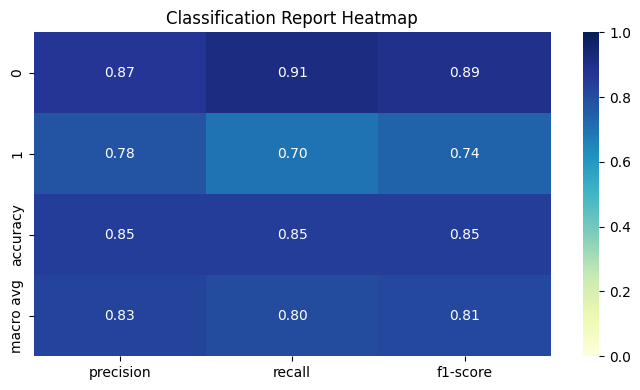

In [97]:
from sklearn.metrics import classification_report
import pandas as pd

report = classification_report(y_test, y_pred_rf, output_dict=True)
report_df = pd.DataFrame(report).transpose().iloc[:-1, :-1]  # drop support & avg rows

plt.figure(figsize=(7, 4))
sns.heatmap(report_df, annot=True, cmap='YlGnBu', fmt='.2f', vmin=0, vmax=1)
plt.title('Classification Report Heatmap')
plt.tight_layout()
plt.show()

# ROC Curve

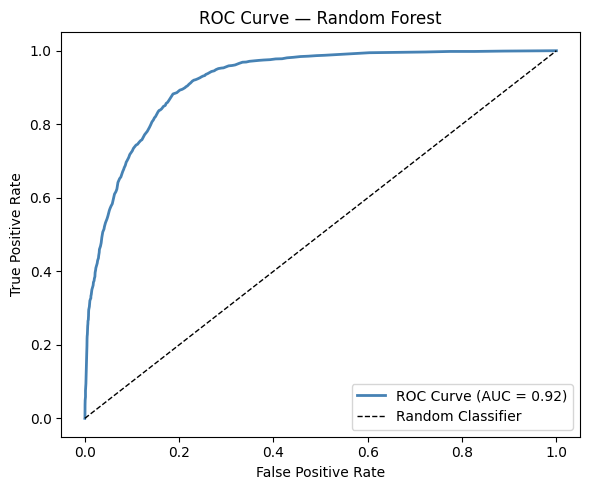

In [98]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='steelblue', lw=2, label=f'ROC Curve (AUC = {auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Random Forest')
plt.legend()
plt.tight_layout()
plt.show()

# Bar Chart — Precision / Recall / F1 per Class

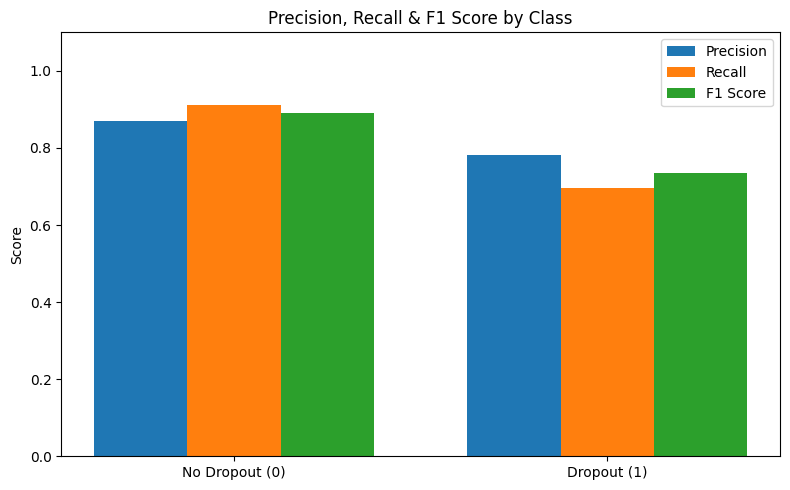

In [99]:
metrics = {
    'Precision': [report['0']['precision'], report['1']['precision']],
    'Recall':    [report['0']['recall'],    report['1']['recall']],
    'F1 Score':  [report['0']['f1-score'],  report['1']['f1-score']],
}

x = ['No Dropout (0)', 'Dropout (1)']
x_pos = range(len(x))
width = 0.25

fig, ax = plt.subplots(figsize=(8, 5))
for i, (metric, values) in enumerate(metrics.items()):
    ax.bar([p + width * i for p in x_pos], values, width, label=metric)

ax.set_xticks([p + width for p in x_pos])
ax.set_xticklabels(x)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('Precision, Recall & F1 Score by Class')
ax.legend()
plt.tight_layout()
plt.show()